In [110]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from warnings import filterwarnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler 
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
filterwarnings('ignore')


### Historical sales dataset ingestion

In [111]:
df = pd.read_csv('../../dataset/Walmart_Data_Analysis_Forcasting.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


### Data preprocessing and feature engineering

In [112]:
df.isnull().sum()
df.isna().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [114]:
# extract day, month, and year

df['Date']=pd.to_datetime(df['Date'],format='%d-%m-%Y')

In [115]:
df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,day,month,year
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,5,2,2010
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,12,2,2010
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,19,2,2010
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,26,2,2010
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,5,3,2010
...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,28,9,2012
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,5,10,2012
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,12,10,2012
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,19,10,2012


### EDA
### Trend and seasonality analysis

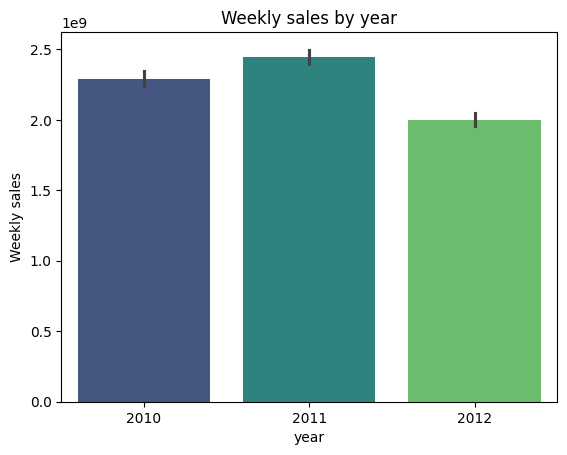

In [116]:
# eda

# week sales by year
plt.Figure(figsize=(10, 5))
sns.barplot(x='year', y='Weekly_Sales', data=df, estimator=sum, palette='viridis')
plt.xlabel('year')
plt.ylabel('Weekly sales')
plt.title(f'Weekly sales by year')
plt.show()


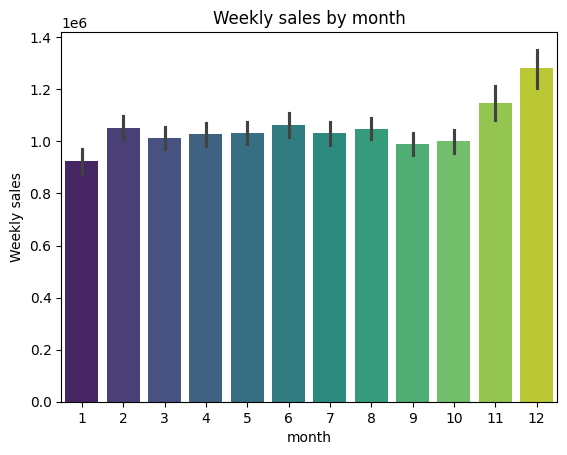

In [117]:
# week sales by month
plt.Figure(figsize=(10, 5))
sns.barplot(x='month', y='Weekly_Sales', data=df, palette='viridis')
plt.xlabel('month')
plt.ylabel('Weekly sales')
plt.title(f'Weekly sales by month')
plt.show()

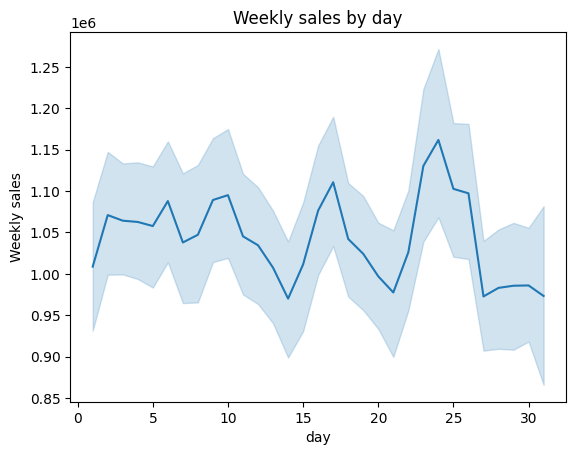

In [118]:
# week sales by month
plt.Figure(figsize=(10, 5))
sns.lineplot(x='day', y='Weekly_Sales', data=df)
plt.xlabel('day')
plt.ylabel('Weekly sales')
plt.title(f'Weekly sales by day')
plt.show()

In [119]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,day,month,year
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,5,2,2010
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,12,2,2010
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,19,2,2010
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,26,2,2010
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,5,3,2010


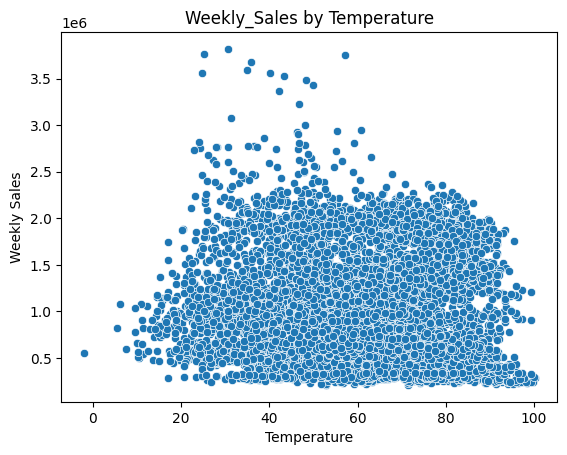

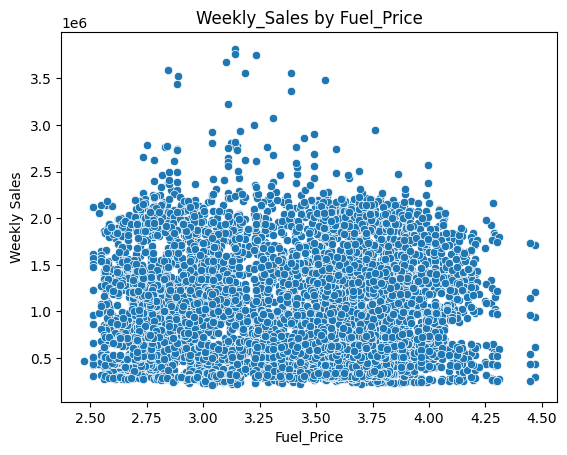

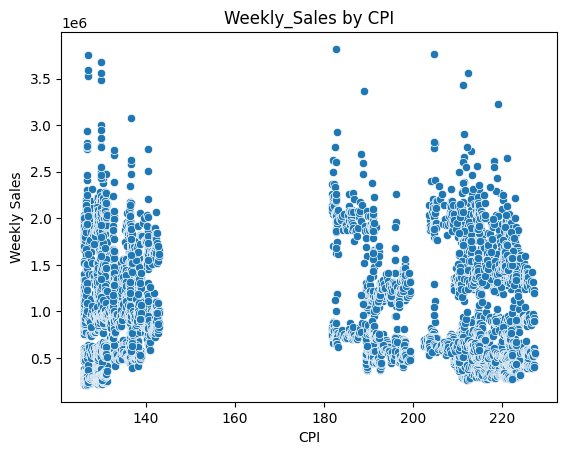

In [120]:
# Scatter plots

columns = ['Temperature', 'Fuel_Price', 'CPI']

for i in columns:
    plt.Figure(figsize=(6, 4))
    sns.scatterplot(x=i, y='Weekly_Sales', data=df)
    plt.xlabel(i)
    plt.ylabel('Weekly Sales')
    plt.title(f'Weekly_Sales by {i}')
    plt.show()

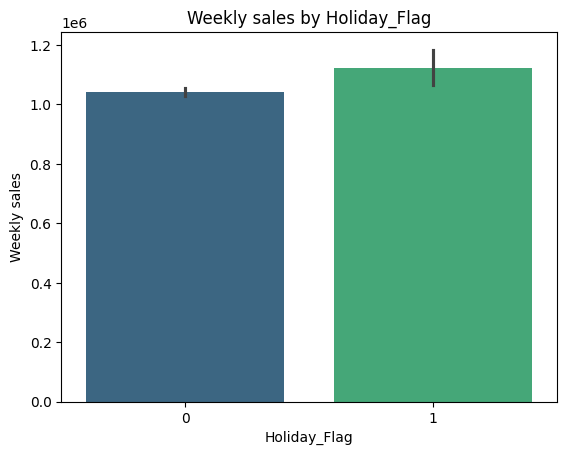

In [121]:
# barplot for hoiday flag

plt.Figure(figsize=(10, 5))
sns.barplot(x='Holiday_Flag', y='Weekly_Sales', data=df, palette='viridis')
plt.xlabel('Holiday_Flag')
plt.ylabel('Weekly sales')
plt.title(f'Weekly sales by Holiday_Flag')
plt.show()

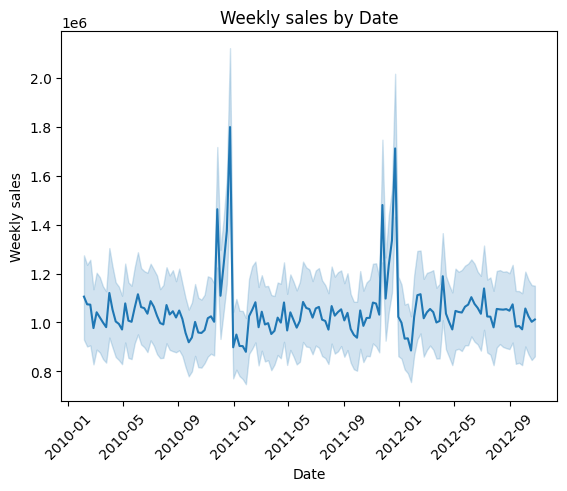

In [122]:
# lineplot for date 
plt.Figure(figsize=(10, 10))
sns.lineplot(x='Date', y='Weekly_Sales', data=df)
plt.xlabel('Date')
plt.ylabel('Weekly sales')
plt.xticks(rotation=45)
plt.title(f'Weekly sales by Date')
plt.show()

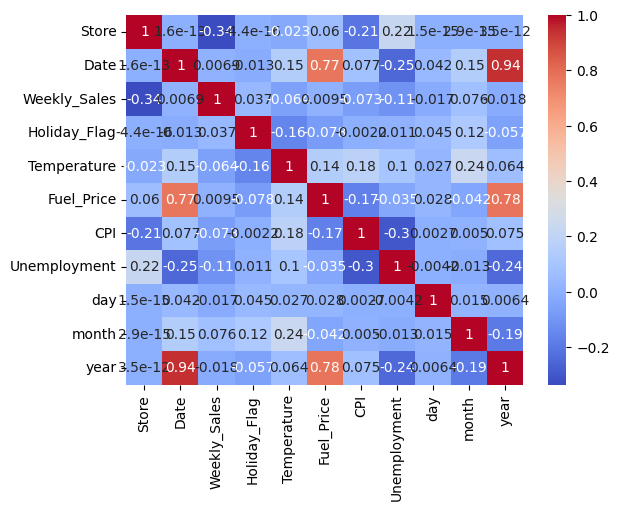

In [123]:
# heatmap

plt.Figure(figsize=(14, 5))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True)
plt.show()

### Machine learning model training

In [124]:

X = df.drop(columns=['Weekly_Sales', 'Date'])
y = df['Weekly_Sales']

In [125]:
# scaling for decision tree 
# using decision true feature select for haveing necessary features
scaler = StandardScaler()
X = scaler.fit_transform(X)



In [ ]:
# training Decision Tree model
dt = DecisionTreeRegressor()
dt.fit(X, y)
selector = SelectFromModel(dt)
X_selected = selector.transform(X)

In [127]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, random_state=42, test_size=0.2)

In [ ]:
# training Linear regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:

y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f'Linear Regression - Mean Squared Error: {mse_lr:.2f}')
print(f'Linear Regression - R-squared: {r2_lr:.2f}')


Linear Regression - Mean Squared Error: 275664002575.04
Linear Regression - R-squared: 0.14


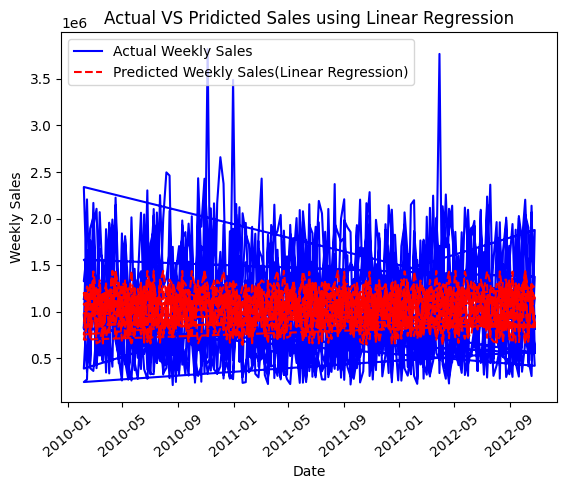

In [130]:
plt.Figure(figsize=(12,6))
plt.plot(df['Date'][len(df)-len(y_test):],y_test, label='Actual Weekly Sales', color='blue')
plt.plot(df['Date'][len(df)-len(y_test):],y_pred_lr, label='Predicted Weekly Sales(Linear Regression)', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.title('Actual VS Pridicted Sales using Linear Regression')
plt.xticks(rotation=40)
plt.legend()
plt.show()


In [135]:
# learning for decision tree
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f'Decision Tree - Mean Squared Error: {mse_dt:.2f}')
print(f'Decision Tree - R-squared: {r2_dt:.2f}')




Decision Tree - Mean Squared Error: 35612554188.30
Decision Tree - R-squared: 0.89


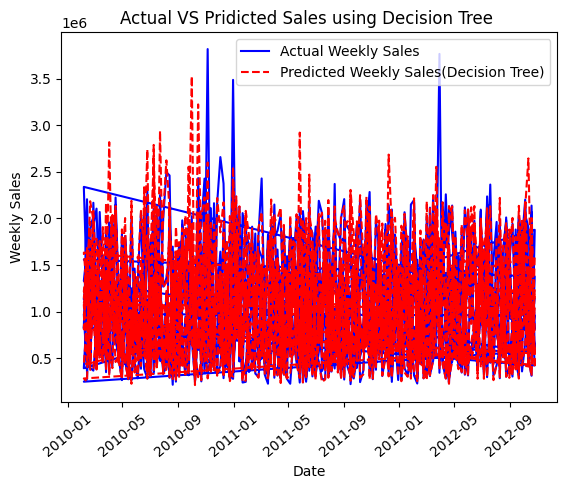

In [133]:
plt.Figure(figsize=(12,6))
plt.plot(df['Date'][len(df)-len(y_test):],y_test, label='Actual Weekly Sales', color='blue')
plt.plot(df['Date'][len(df)-len(y_test):],y_pred_dt, label='Predicted Weekly Sales(Decision Tree)', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.title('Actual VS Pridicted Sales using Decision Tree ')
plt.xticks(rotation=40)
plt.legend()
plt.show()


In [ ]:
# learning for random forest 

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'Random Forest - Mean Squared Error: {mse_rf:.2f}')
print(f'Random Forest - R-squared: {r2_rf:.2f}')


Decision Tree - Mean Squared Error: 26597912410.23
Decision Tree - R-squared: 0.92


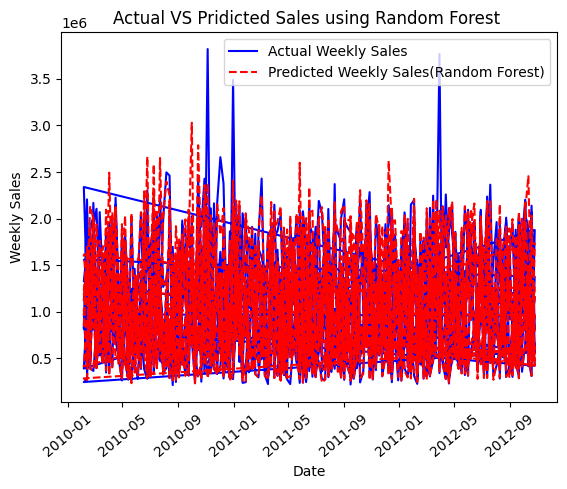

In [137]:
plt.Figure(figsize=(12,6))
plt.plot(df['Date'][len(df)-len(y_test):],y_test, label='Actual Weekly Sales', color='blue')
plt.plot(df['Date'][len(df)-len(y_test):],y_pred_rf, label='Predicted Weekly Sales(Random Forest)', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.title('Actual VS Pridicted Sales using Random Forest ')
plt.xticks(rotation=40)
plt.legend()
plt.show()